In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/review/reviews_eda_processed.csv


In [2]:
df = pd.read_csv('/kaggle/input/review/reviews_eda_processed.csv')

In [3]:
df

,category,rating,label,text_,review_length,word_count,sentiment_polarity,readability,syntactic_complexity
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor...",75,18,0.473750,4.450000,6.000000
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I...",80,19,0.558333,3.017500,9.500000
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...,67,16,0.250000,0.625714,8.000000
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i...",81,19,0.400000,6.310588,9.500000
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...,85,20,0.740000,1.686667,6.666667
...,...,...,...,...,...,...,...,...,...
40427,Clothing_Shoes_and_Jewelry_5,4.0,OR,I had read some reviews saying that this bra r...,1694,379,0.190431,6.095160,17.227273
40428,Clothing_Shoes_and_Jewelry_5,5.0,CG,I wasn't sure exactly what it would be. It is ...,1304,311,0.298208,2.884552,11.107143
40429,Clothing_Shoes_and_Jewelry_5,2.0,OR,"You can wear the hood by itself, wear it with ...",1987,414,0.054640,6.012773,15.923077
40430,Clothing_Shoes_and_Jewelry_5,1.0,CG,I liked nothing about this dress. The only rea...,1301,334,0.298997,2.370763,12.846154


2025-12-27 14:07:55.913879: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766844476.068842      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766844476.108764      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766844476.468132      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766844476.468179      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766844476.468182      55 computation_placer.cc:177] computation placer alr

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

trainable params: 887,042 || all params: 125,534,212 || trainable%: 0.7066


/tmp/ipykernel_55/3777392078.py:129: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.287000,0.235345,0.903302,0.875432,0.940391,0.906749,0.971630
2,0.218300,0.194502,0.923457,0.894834,0.959683,0.926125,0.983927
3,0.192600,0.168114,0.935205,0.914879,0.959683,0.936746,0.986732


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(



=== FINAL METRICS ===
Accuracy  : 0.9352
Precision : 0.9149
Recall    : 0.9597
F1-score  : 0.9367
ROC-AUC   : 0.9867


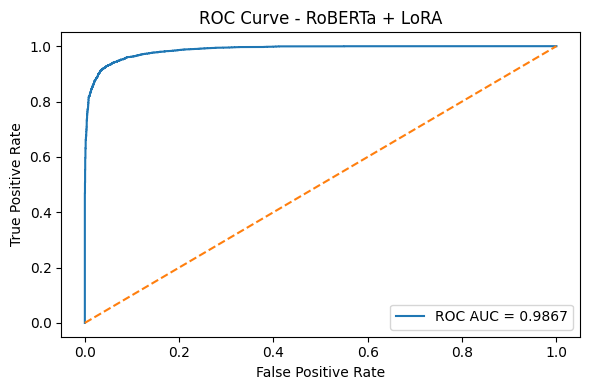

Model saved successfully.


In [4]:
# ===============================
# 1. IMPORTS
# ===============================
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve
)

from transformers import (
    RobertaTokenizer,
    RobertaForSequenceClassification,
    Trainer,
    TrainingArguments
)

from peft import LoraConfig, get_peft_model, TaskType
from datasets import Dataset

# ===============================
# 2. LOAD DATA
# ===============================
df = pd.read_csv('/kaggle/input/review/reviews_eda_processed.csv')

# Map labels
label_map = {"OR": 0, "CG": 1}
df["label"] = df["label"].map(label_map)

texts = df["text_"].astype(str)
labels = df["label"].astype(int)

# ===============================
# 3. TRAIN TEST SPLIT (80/20)
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    texts, labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

train_df = pd.DataFrame({"text": X_train, "label": y_train})
test_df  = pd.DataFrame({"text": X_test, "label": y_test})

train_ds = Dataset.from_pandas(train_df)
test_ds  = Dataset.from_pandas(test_df)

# ===============================
# 4. TOKENIZATION
# ===============================
tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=256
    )

train_ds = train_ds.map(tokenize, batched=True)
test_ds  = test_ds.map(tokenize, batched=True)

train_ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])
test_ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])

# ===============================
# 5. LOAD ROBERTA + LoRA
# ===============================
base_model = RobertaForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=2
)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["query", "value"]
)

model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()

# ===============================
# 6. TRAINING ARGUMENTS
# ===============================
training_args = TrainingArguments(
    output_dir="./roberta_lora",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="none"
)

# ===============================
# 7. METRICS FUNCTION
# ===============================
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()
    preds = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds),
        "recall": recall_score(labels, preds),
        "f1": f1_score(labels, preds),
        "roc_auc": roc_auc_score(labels, probs)
    }

# ===============================
# 8. TRAIN
# ===============================
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

trainer.train()

# ===============================
# 9. EVALUATION
# ===============================
preds = trainer.predict(test_ds)

logits = preds.predictions
y_true = preds.label_ids
y_probs = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()
y_pred = np.argmax(logits, axis=1)

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec  = recall_score(y_true, y_pred)
f1   = f1_score(y_true, y_pred)
auc  = roc_auc_score(y_true, y_probs)

print("\n=== FINAL METRICS ===")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-score  : {f1:.4f}")
print(f"ROC-AUC   : {auc:.4f}")

# ===============================
# 10. ROC CURVE
# ===============================
fpr, tpr, _ = roc_curve(y_true, y_probs)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"ROC AUC = {auc:.4f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - RoBERTa + LoRA")
plt.legend()
plt.tight_layout()
plt.show()

# ===============================
# 11. SAVE MODEL
# ===============================
model.save_pretrained("roberta_lora_fake_review")
tokenizer.save_pretrained("roberta_lora_fake_review")

print("Model saved successfully.")

In [5]:
import torch
import numpy as np
from transformers import RobertaTokenizer, RobertaForSequenceClassification
from peft import PeftModel

# -------------------------------
# DEVICE
# -------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------------------
# LOAD TOKENIZER + MODEL
# -------------------------------
tokenizer = RobertaTokenizer.from_pretrained("roberta_lora_fake_review")

base_model = RobertaForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=2
)

model = PeftModel.from_pretrained(base_model, "roberta_lora_fake_review")
model.to(device)
model.eval()

# -------------------------------
# HARDCODED RANDOM REVIEWS
# -------------------------------
reviews = [
    "Absolutely fantastic product! Exceeded all my expectations and works flawlessly.",
    "This item was okay, nothing special. Packaging was damaged but the product works.",
    "I have never seen such an amazing product in my life!!! Highly recommended to everyone!!!",
    "The quality is poor and it stopped working after two days. Very disappointed.",
    "Best purchase ever. Five stars. Will definitely buy again and again!!!"
]

label_map = {0: "OR", 1: "CG"}

# -------------------------------
# PREDICT
# -------------------------------
print("\n=== PREDICTIONS ===\n")

with torch.no_grad():
    for text in reviews:
        inputs = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            padding="max_length",
            max_length=256
        ).to(device)

        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()[0]

        pred_class = np.argmax(probs)
        pred_label = label_map[pred_class]
        cg_prob = probs[1]

        print(f"Review: {text}")
        print(f"Predicted Label: {pred_label}")
        print(f"CG Probability: {cg_prob:.4f}")
        print("-" * 70)


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



=== PREDICTIONS ===

Review: Absolutely fantastic product! Exceeded all my expectations and works flawlessly.
Predicted Label: OR
CG Probability: 0.1731
----------------------------------------------------------------------
Review: This item was okay, nothing special. Packaging was damaged but the product works.
Predicted Label: OR
CG Probability: 0.3753
----------------------------------------------------------------------
Review: I have never seen such an amazing product in my life!!! Highly recommended to everyone!!!
Predicted Label: OR
CG Probability: 0.0058
----------------------------------------------------------------------
Review: The quality is poor and it stopped working after two days. Very disappointed.
Predicted Label: CG
CG Probability: 0.6842
----------------------------------------------------------------------
Review: Best purchase ever. Five stars. Will definitely buy again and again!!!
Predicted Label: OR
CG Probability: 0.0424
-------------------------------------

Map:   0%|          | 0/32345 [00:00<?, ? examples/s]

Map:   0%|          | 0/8087 [00:00<?, ? examples/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipykernel_55/18174576.py:137: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


trainable params: 887,042 || all params: 125,534,212 || trainable%: 0.7066


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.298700,0.225989,0.901447,0.880629,0.928766,0.904057,0.972334
2,0.232100,0.178603,0.925560,0.911308,0.942864,0.926817,0.983323
3,0.202000,0.167404,0.930382,0.912713,0.951768,0.931832,0.985938


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(



=== FINAL METRICS ===
Accuracy  : 0.9304
Precision : 0.9127
Recall    : 0.9518
F1-score  : 0.9318
ROC-AUC   : 0.9859


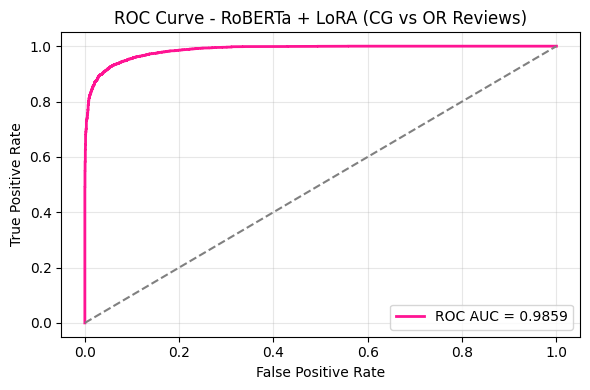

RoBERTa + LoRA model and tokenizer saved successfully to 'roberta_lora_fake_review'


In [7]:
# ===============================
# 1. IMPORTS
# ===============================
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve
)

from transformers import (
    RobertaTokenizer,
    RobertaForSequenceClassification,
    Trainer,
    TrainingArguments
)

from peft import LoraConfig, get_peft_model
from datasets import Dataset

# ===============================
# 2. LOAD DATA
# ===============================
df = pd.read_csv('/kaggle/input/review/reviews_eda_processed.csv')

# Ensure labels are 0 (OR) and 1 (CG)
label_map = {"OR": 0, "CG": 1}
df["label"] = df["label"].map(label_map)

# Use the processed text column
texts = df["text_"].astype(str).tolist()
labels = df["label"].astype(int).tolist()

# ===============================
# 3. TRAIN TEST SPLIT (80/20)
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    texts, labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

train_df = pd.DataFrame({"text": X_train, "label": y_train})
test_df  = pd.DataFrame({"text": X_test, "label": y_test})

train_ds = Dataset.from_pandas(train_df)
test_ds  = Dataset.from_pandas(test_df)

# ===============================
# 4. TOKENIZATION
# ===============================
tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=256
    )

train_ds = train_ds.map(tokenize, batched=True)
test_ds  = test_ds.map(tokenize, batched=True)

# Important: rename 'label' → 'labels' for Trainer
train_ds = train_ds.rename_column("label", "labels")
test_ds  = test_ds.rename_column("label", "labels")

train_ds.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
test_ds.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

# ===============================
# 5. LOAD ROBERTA + LoRA
# ===============================
base_model = RobertaForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=2
)

lora_config = LoraConfig(
    task_type="SEQ_CLS",
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["query", "value"]
)

model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()

# ===============================
# 6. TRAINING ARGUMENTS (Fixed for latest Transformers)
# ===============================
training_args = TrainingArguments(
    output_dir="./roberta_lora",
    eval_strategy="epoch",           # ← updated from evaluation_strategy
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    report_to="none",
    warmup_steps=100,
    fp16=True if torch.cuda.is_available() else False,  # use mixed precision on GPU
)

# ===============================
# 7. METRICS FUNCTION
# ===============================
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    probs = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()

    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds),
        "recall": recall_score(labels, preds),
        "f1": f1_score(labels, preds),
        "roc_auc": roc_auc_score(labels, probs)
    }

# ===============================
# 8. TRAIN
# ===============================
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

trainer.train()

# ===============================
# 9. EVALUATION
# ===============================
preds = trainer.predict(test_ds)
logits = preds.predictions
y_true = preds.label_ids
y_probs = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()
y_pred = np.argmax(logits, axis=1)

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec  = recall_score(y_true, y_pred)
f1   = f1_score(y_true, y_pred)
auc  = roc_auc_score(y_true, y_probs)

print("\n=== FINAL METRICS ===")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-score  : {f1:.4f}")
print(f"ROC-AUC   : {auc:.4f}")

# ===============================
# 10. ROC CURVE
# ===============================
fpr, tpr, _ = roc_curve(y_true, y_probs)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"ROC AUC = {auc:.4f}", color="deeppink", linewidth=2)
plt.plot([0, 1], [0, 1], '--', color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - RoBERTa + LoRA (CG vs OR Reviews)")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ===============================
# 11. SAVE MODEL
# ===============================
model.save_pretrained("roberta_lora_fake_review")
tokenizer.save_pretrained("roberta_lora_fake_review")
print("RoBERTa + LoRA model and tokenizer saved successfully to 'roberta_lora_fake_review'")